In [7]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from sklearn.metrics.pairwise import cosine_similarity

In [8]:
spark = SparkSession.builder.master("local[*]").getOrCreate()

spark.conf.set("spark.sql.legacy.parquet.nanosAsLong", "true")

In [9]:
# Read the files
logs_df = spark.read.parquet("/mnt/data/public/noaa-ais/2023_NOAA_AIS_logs_*.parquet")
ships_df = spark.read.parquet("/mnt/data/public/noaa-ais/2023_NOAA_AIS_ships_*.parquet")

# Temporal Analysis Using Line Chart

For `BaseDateTime`, it was converted from its original nanosecond timestamp into a standard timestamp type so that it can be easily interpreted, aggregated, and analyzed by time.

In [10]:
logs_df = logs_df.withColumn(
    "BaseDateTime",
    F.to_timestamp((F.col("BaseDateTime").cast("double") / 1_000_000_000).cast("long")),
)

logs_df.select("BaseDateTime").show(2)

+-------------------+
|       BaseDateTime|
+-------------------+
|2023-01-01 08:00:00|
|2023-01-01 08:00:00|
+-------------------+
only showing top 2 rows



We then joined logs_df and ships_df so that we can have the cargo type.

In [11]:
logs_with_vessel = logs_df.join(
    ships_df.select("MMSI", "VesselType"),  # only need MMSI and Vessel
    on="MMSI",
    how="left",  # keep all log rows even if Vessel is missing
)

logs_with_vessel.show(2)

+---------+-------------------+--------+---------+---+-----+-------+----------+
|     MMSI|       BaseDateTime|     LAT|      LON|SOG|  COG|Heading|VesselType|
+---------+-------------------+--------+---------+---+-----+-------+----------+
|129129903|2023-01-01 08:00:00|18.81136|-66.46386|6.5|338.8|  338.0|      36.0|
|129129903|2023-01-01 08:00:00|18.81136|-66.46386|6.5|338.8|  338.0|      36.0|
+---------+-------------------+--------+---------+---+-----+-------+----------+
only showing top 2 rows



In [12]:
# Create mapping from AIS Vessel Code to Vessel Group
ais_to_group = {}

# Not Available
ais_to_group[0] = "Not Available"
ais_to_group[np.nan] = "Not Available"

# Other codes
ais_to_group.update({i: "Other" for i in range(1, 20)})
ais_to_group.update({i: "Other" for i in range(23, 30)})
ais_to_group.update({i: "Other" for i in range(33, 36)})
ais_to_group.update({i: "Other" for i in range(38, 41)})
ais_to_group.update({i: "Other" for i in range(45, 60)})
ais_to_group.update({i: "Other" for i in range(90, 1000)})  # future/regional

# Tug/Tow
ais_to_group.update(
    {21: "Tug Tow", 22: "Tug Tow", 31: "Tug Tow", 32: "Tug Tow", 52: "Tug Tow"}
)

# Fishing
ais_to_group[30] = "Fishing"

# Military
ais_to_group[35] = "Military"

# Pleasure Craft / Sailing
ais_to_group[36] = "Pleasure Craft/Sailing"
ais_to_group[37] = "Pleasure Craft/Sailing"

# Passenger
ais_to_group.update({i: "Passenger" for i in range(60, 70)})

# Cargo
ais_to_group.update({i: "Cargo" for i in range(70, 80)})

# Tanker
ais_to_group.update({i: "Tanker" for i in range(80, 90)})

## By Month

In [13]:
monthly_vessel_counts = (
    logs_with_vessel
    # truncate timestamp to the month
    .withColumn("Month", F.date_trunc("month", "BaseDateTime"))
    # group by vessel type and month
    .groupBy("VesselType", "Month")
    # count distinct ships per group
    .agg(F.countDistinct("MMSI").alias("NumShips"))
    # order by month and vessel type
    .orderBy("Month", "VesselType")
)

In [14]:
parquet_path = "data/monthly_vessel_counts.parquet"

if not os.path.exists(parquet_path):
    # Only save if the file doesn't exist
    monthly_vessel_counts.write.mode("overwrite").parquet(parquet_path)

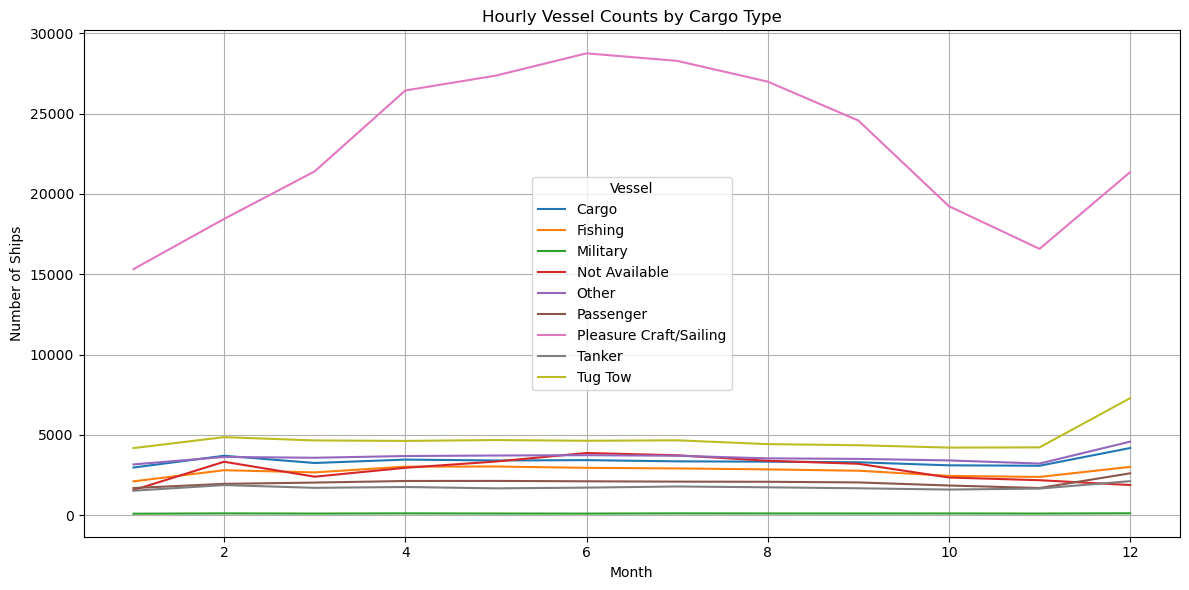

In [15]:
monthly_vessel_counts_df = pd.read_parquet(parquet_path)
monthly_vessel_counts_df["Month"] = monthly_vessel_counts_df["Month"].dt.month
monthly_vessel_counts_df["Vessel Name"] = monthly_vessel_counts_df["VesselType"].map(
    ais_to_group
)
monthly_vessel_counts_agg = monthly_vessel_counts_df.groupby(
    ["Month", "Vessel Name"], as_index=False
)["NumShips"].sum()
monthly_vessel_counts_pivot = monthly_vessel_counts_agg.pivot(
    index="Month", columns="Vessel Name", values="NumShips"
)

plt.figure(figsize=(12, 6))
monthly_vessel_counts_pivot.plot(ax=plt.gca())

plt.xlabel("Month")
plt.ylabel("Number of Ships")
plt.title("Hourly Vessel Counts by Cargo Type")
plt.legend(title="Vessel")
plt.grid(True)
plt.tight_layout()
plt.show()

## By Hour

In [16]:
hourly_vessel_counts = (
    # truncate timestamp to the hour
    logs_with_vessel.withColumn("Hour", F.date_trunc("hour", "BaseDateTime"))
    # remove repeated logs for the same ship in the same hour
    .dropDuplicates(["MMSI", "Hour"])
    # group by vessel type and hour
    .groupBy("VesselType", "Hour")
    # count unique ships per group
    .agg(F.count("MMSI").alias("NumShips"))
    # order by time and vessel
    .orderBy("Hour", "VesselType")
)

In [17]:
parquet_path = "data/hourlies_cargo_counts.parquet"

if not os.path.exists(parquet_path):
    # Only save if the file doesn't exist
    hourly_vessel_counts.write.mode("overwrite").parquet(parquet_path)

We create a mapping from AIS Vessel Code to Vessel Group based on the [Marine Cadastre Project (2018)](https://coast.noaa.gov/data/marinecadastre/ais/VesselTypeCodes2018.pdf).


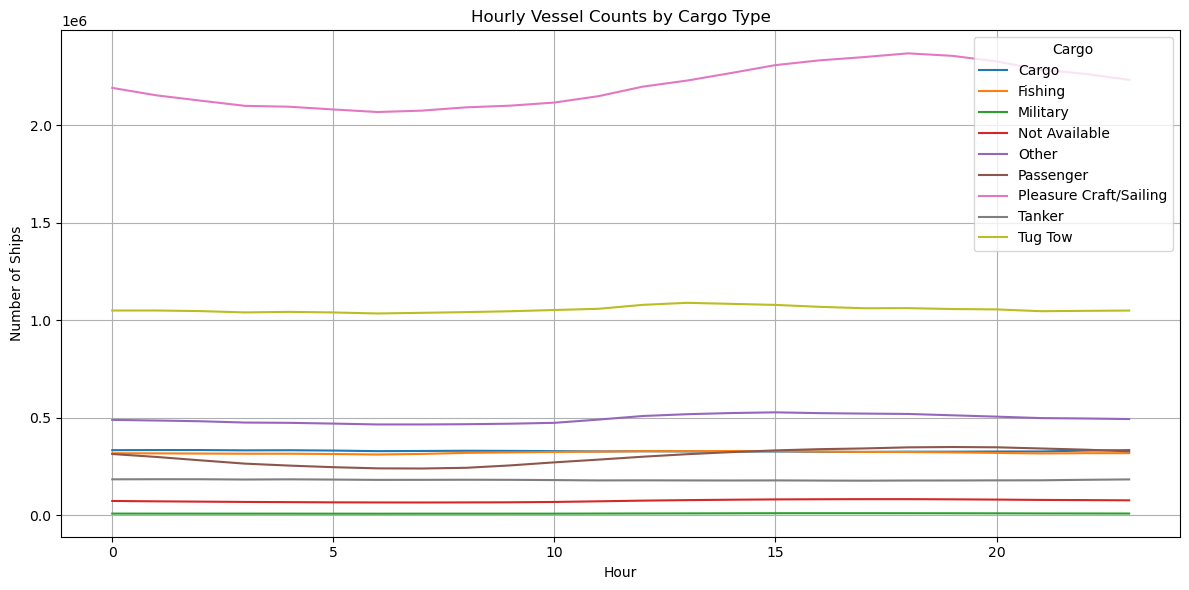

In [18]:
hourly_cargo_counts_df = pd.read_parquet(parquet_path)
hourly_cargo_counts_df["Hour"] = hourly_cargo_counts_df["Hour"].dt.hour
hourly_cargo_counts_df["Vessel Name"] = hourly_cargo_counts_df["VesselType"].map(
    ais_to_group
)
hourly_cargo_counts_agg = hourly_cargo_counts_df.groupby(
    ["Hour", "Vessel Name"], as_index=False
)["NumShips"].sum()
hourly_cargo_counts_pivot = hourly_cargo_counts_agg.pivot(
    index="Hour", columns="Vessel Name", values="NumShips"
)

plt.figure(figsize=(12, 6))
hourly_cargo_counts_pivot.plot(ax=plt.gca())

plt.xlabel("Hour")
plt.ylabel("Number of Ships")
plt.title("Hourly Vessel Counts by Cargo Type")
plt.legend(title="Cargo")
plt.grid(True)
plt.tight_layout()
plt.show()

# Vessel Type Traffic Dominance Using Bar Charts

In [19]:
# Compute monthly totals per vessel
monthly_totals = (
    monthly_vessel_counts_df.groupby(["Month", "Vessel Name"])["NumShips"]
    .sum()
    .reset_index()
)

# Compute total ships per month
month_totals = monthly_totals.groupby("Month")["NumShips"].transform("sum")

# Compute percentage per vessel per month
monthly_totals["Percentage"] = monthly_totals["NumShips"] / month_totals * 100

# Pivot: rows = Vessel Name, columns = Month, values = Percentage
monthly_percentage = monthly_totals.pivot(
    index="Vessel Name", columns="Month", values="Percentage"
).fillna(
    0
)  # fill NaN with 0 if a vessel didn't appear in a month

# Compute cosine similarity between consecutive months
months = monthly_percentage.columns.tolist()
cosine_similarities = {}

for i in range(len(months)):
    month1 = months[i]
    month2 = months[(i + 1) % len(months)]  # wrap around 12 -> 1
    vec1 = monthly_percentage[month1].values.reshape(1, -1)
    vec2 = monthly_percentage[month2].values.reshape(1, -1)

    sim = cosine_similarity(vec1, vec2)[0][0]
    cosine_similarities[f"{month1}->{month2}"] = sim

# Convert results to a DataFrame for easier viewing
cosine_sim_df = pd.DataFrame(
    list(cosine_similarities.items()), columns=["Month Pair", "Cosine Similarity"]
)

cosine_sim_df

,Month Pair,Cosine Similarity
0,1->2,0.997309
1,2->3,0.995802
2,3->4,0.998585
3,4->5,0.999897
4,5->6,0.999818
5,6->7,0.999984
6,7->8,0.999961
7,8->9,0.999774
8,9->10,0.998252
9,10->11,0.998958


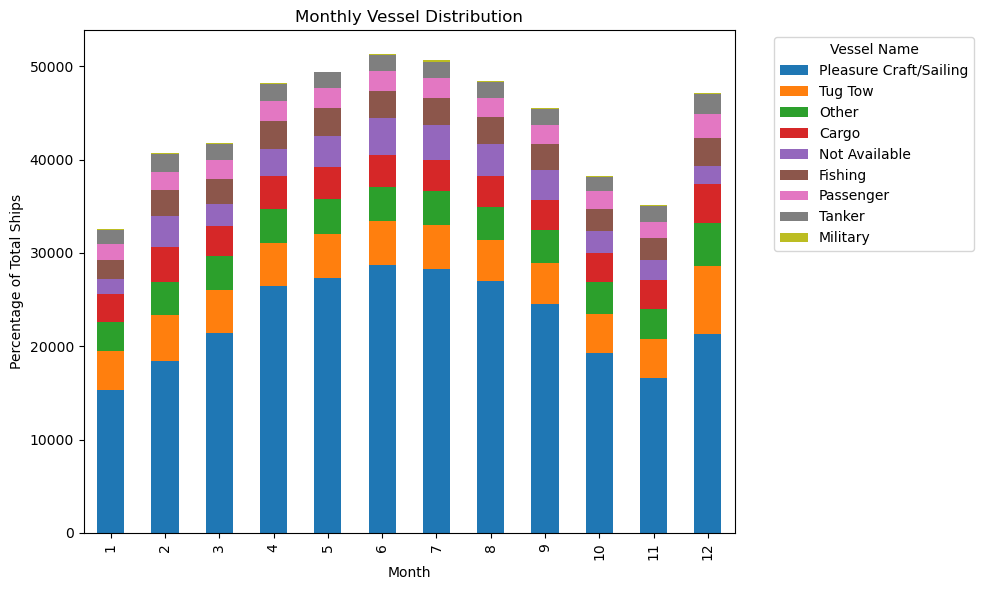

In [20]:
# Pivot the data
monthly_pivot = monthly_totals.pivot(
    index="Month", columns="Vessel Name", values="NumShips"
).fillna(0)

# Sort vessel types by their overall average (largest at bottom)
vessel_order = monthly_pivot.mean().sort_values(ascending=False).index
monthly_pivot = monthly_pivot[vessel_order]

# Plot stacked bar chart
monthly_pivot.plot(kind="bar", stacked=True, figsize=(10, 6))

plt.title("Monthly Vessel Distribution")
plt.xlabel("Month")
plt.ylabel("Percentage of Total Ships")
plt.legend(title="Vessel Name", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Speed (`SOG`) to Activity Relationship Using Scatterplots

In [21]:
ships_df.describe(['Length', 'Width']).show()

+-------+-----------------+------------------+
|summary|           Length|             Width|
+-------+-----------------+------------------+
|  count|           455496|            404242|
|   mean|45.13784094701161| 9.657964783471288|
| stddev|73.02293616288846|11.061397739623729|
|    min|              0.0|               0.0|
|    max|           1022.0|             126.0|
+-------+-----------------+------------------+



In [ ]:
# Use logs_df for ships (we needed a temp variable to do .limit(1000))
parquet_dir = "/mnt/data/public/noaa-ais/"

# List all 2023 Parquet files except the corrupted one
files_to_read = [
    os.path.join(parquet_dir, f)
    for f in os.listdir(parquet_dir)
    if f.startswith("2023_NOAA_AIS_logs") and f != "2023_NOAA_AIS_logs_04.parquet"
]

logs_skipped_04_df = spark.read.parquet(*files_to_read)

logs_skipped_04_df = logs_skipped_04_df.withColumn(
    "BaseDateTime",
    F.to_timestamp((F.col("BaseDateTime").cast("double") / 1_000_000_000).cast("long")),
)

ships = logs_skipped_04_df

# Round timestamp to nearest minute
ships = ships.withColumn("Minute", F.date_trunc("minute", F.col("BaseDateTime")))

# Delta for latitude/longitude bounds (of around 5 km)
delta = 0.05

# Self-join using LAT/LON bounds to find nearby ships
nearby = ships.alias("a").join(
    ships.alias("b"),
    (F.col("a.Minute") == F.col("b.Minute"))  # same minute
    & (F.col("a.MMSI") != F.col("b.MMSI"))    # different ships
    & (F.col("b.LAT").between(F.col("a.LAT") - delta, F.col("a.LAT") + delta))
    & (F.col("b.LON").between(F.col("a.LON") - delta, F.col("a.LON") + delta))
)

# Count nearby ships per vessel per minute
nearby_count = nearby.groupBy("a.MMSI", "a.Minute").agg(
    F.countDistinct("b.MMSI").alias("num_nearby_ships")
)

# Join nearby ship counts back to original dataframe
ships_with_density = ships.join(
    nearby_count, on=["MMSI", "Minute"], how="left"
).fillna({"num_nearby_ships": 0})

# Save to parquet if the file doesn't exist
parquet_path = "data/SOG_nearby_ships.parquet"
if not os.path.exists(parquet_path):
    ships_with_density.write.mode("overwrite").parquet(parquet_path)